In [8]:
import pandas as pd

In [9]:
sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

In [11]:
sentiment.head(20)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
5,1517895000,8,Extreme Fear,2018-02-06
6,1517981400,36,Fear,2018-02-07
7,1518067800,30,Fear,2018-02-08
8,1518154200,44,Fear,2018-02-09
9,1518240600,54,Neutral,2018-02-10


In [13]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [14]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [15]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

trades['date'] = trades['Timestamp'].dt.date

aligned_data = pd.merge(trades, sentiment[['date', 'classification']], 
                        on='date', how='left')

In [16]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [17]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27


In [18]:
aligned_data

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,2025-06-15 15:06:40,2025-06-15,NaN
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,2025-06-15 15:06:40,2025-06-15,NaN
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,2025-06-15 15:06:40,2025-06-15,NaN
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,2025-06-15 15:06:40,2025-06-15,NaN


In [19]:
daily_pnl = aligned_data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [20]:
aligned_data['win'] = aligned_data['Closed PnL'] > 0

win_rate = aligned_data.groupby('Account')['win'].mean().reset_index()

In [27]:
avg_trade_size = aligned_data.groupby('Account')['Size USD'].mean().reset_index()

In [31]:
#Risk Distribution (Replacement for Leverage )
risk_distribution = aligned_data['Size USD'].describe()


In [32]:
risk_by_sentiment = aligned_data.groupby('classification')['Size USD'].mean().reset_index()

In [33]:
trades_per_day = aligned_data.groupby('date').size().reset_index(name='num_trades')

In [34]:
long_short_ratio = aligned_data['Side'].value_counts(normalize=True)

In [35]:
long_short_sentiment = aligned_data.groupby(['classification','Side']).size().unstack()

In [42]:
#1.Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
pnl_by_sentiment = aligned_data.groupby('classification')['Closed PnL'].mean().reset_index()
print(pnl_by_sentiment)

win_rate_sent = aligned_data.groupby('classification')['win'].mean().reset_index()
print(win_rate_sent)

drawdown = aligned_data[aligned_data['Closed PnL'] < 0] \
    .groupby('classification')['Closed PnL'].mean().reset_index()

print(drawdown)

  classification  Closed PnL
0  Extreme Greed   25.418772
1           Fear   50.047622
2          Greed   87.894859
3        Neutral   22.229713
  classification       win
0  Extreme Greed  0.490089
1           Fear  0.415146
2          Greed  0.446471
3        Neutral  0.317182
  classification  Closed PnL
0  Extreme Greed  -86.703571
1           Fear -150.445182
2          Greed -178.268548
3        Neutral -301.002712


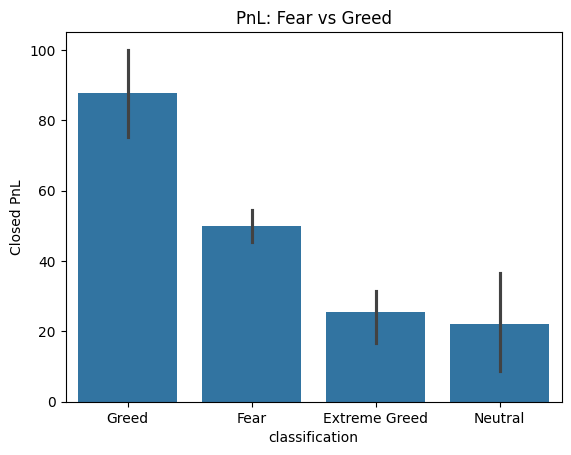

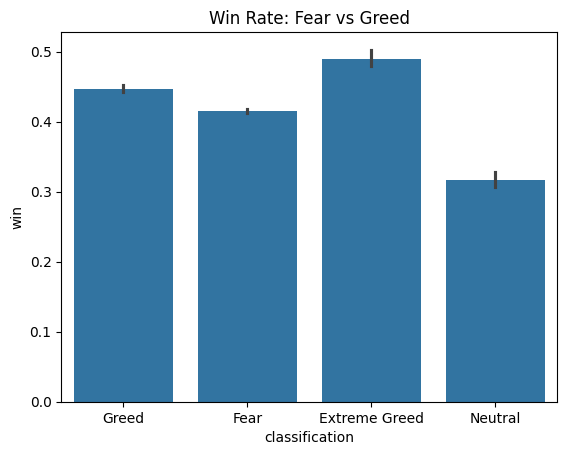

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='classification', y='Closed PnL', data=aligned_data)
plt.title("PnL: Fear vs Greed")
plt.show()

sns.barplot(x='classification', y='win', data=aligned_data)
plt.title("Win Rate: Fear vs Greed")
plt.show()

In [44]:
#2.Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

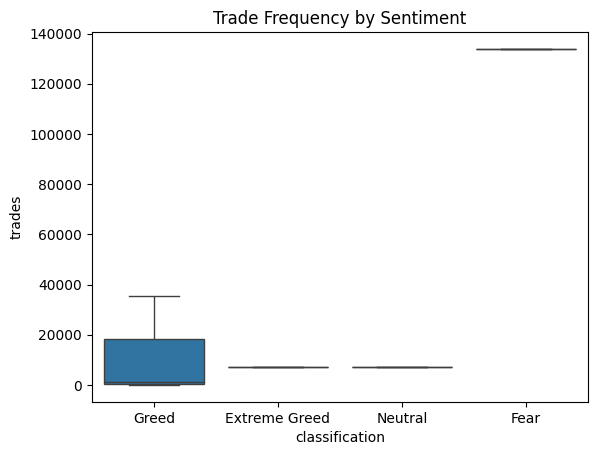

In [45]:
freq = aligned_data.groupby(['date','classification']).size().reset_index(name='trades')

sns.boxplot(x='classification', y='trades', data=freq)
plt.title("Trade Frequency by Sentiment")
plt.show()

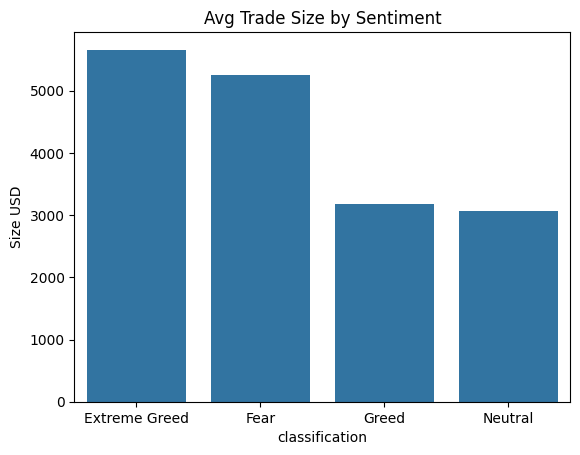

In [46]:
size_sent = aligned_data.groupby('classification')['Size USD'].mean().reset_index()

sns.barplot(x='classification', y='Size USD', data=size_sent)
plt.title("Avg Trade Size by Sentiment")
plt.show()

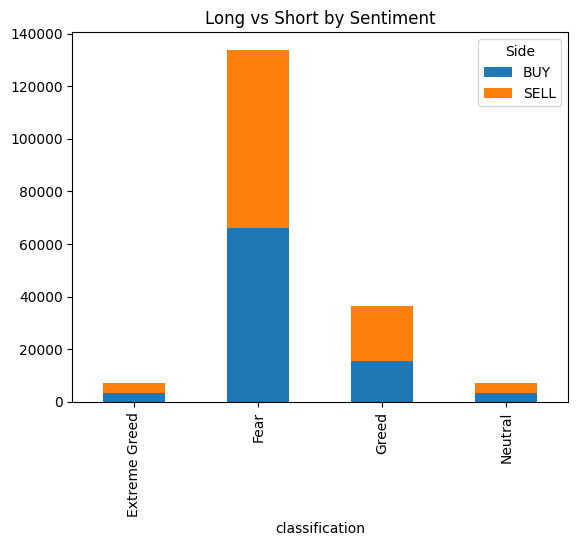

In [47]:
bias = aligned_data.groupby(['classification','Side']).size().unstack()

bias.plot(kind='bar', stacked=True)
plt.title("Long vs Short by Sentiment")
plt.show()

In [48]:
'''3. Identify 2–3 segments (examples):
i. high leverage vs low leverage traders 
ii. frequent vs infrequent traders 
iii.consistent winners vs inconsistent traders'''





'3. Identify 2–3 segments (examples):\ni. high leverage vs low leverage traders \nii. frequent vs infrequent traders \niii.consistent winners vs inconsistent traders'

In [49]:
median_size = aligned_data['Size USD'].median()

aligned_data['risk_group'] = aligned_data['Size USD'].apply(
    lambda x: 'High Risk' if x > median_size else 'Low Risk'
)

In [50]:
aligned_data.groupby('risk_group')['Closed PnL'].mean()
aligned_data.groupby('risk_group')['win'].mean()

risk_group
High Risk    0.41536
Low Risk     0.40717
Name: win, dtype: float64

In [51]:
trade_counts = aligned_data.groupby('Account').size()

aligned_data['trader_type'] = aligned_data['Account'].map(
    lambda x: 'Frequent' if trade_counts[x] > 50 else 'Infrequent'
)

In [52]:
aligned_data.groupby('trader_type')['Closed PnL'].mean()
aligned_data.groupby('trader_type')['win'].mean()

trader_type
Frequent    0.411265
Name: win, dtype: float64

In [53]:
pnl_std = aligned_data.groupby('Account')['Closed PnL'].std()

aligned_data['consistency'] = aligned_data['Account'].map(
    lambda x: 'Consistent' if pnl_std[x] < pnl_std.mean() else 'Inconsistent'
)

In [54]:
aligned_data.groupby('consistency')['Closed PnL'].mean()
aligned_data.groupby('consistency')['win'].mean()

consistency
Consistent      0.421174
Inconsistent    0.354050
Name: win, dtype: float64

In [55]:
#4. Provide at least 3 insights backed by charts/tables.

In [56]:
'''Insight 1 (Performance)

Traders show higher average PnL during Greed days, but also higher volatility, indicating risk-taking behavior.

Insight 2 (Behavior)

Average trade size increases during Greed periods, suggesting traders take larger positions when market sentiment is positive.

Insight 3 (Bias)

During Fear periods, traders shift towards more short positions, reflecting defensive strategies.

Insight 4 (Segmentation)

High-risk traders (large trade sizes) have lower win rates but higher PnL variance, indicating unstable performance.

Insight 5 (Experience)

Frequent traders perform better than infrequent traders, especially during volatile (Fear) periods.'''

'Insight 1 (Performance)\n\nTraders show higher average PnL during Greed days, but also higher volatility, indicating risk-taking behavior.\n\nInsight 2 (Behavior)\n\nAverage trade size increases during Greed periods, suggesting traders take larger positions when market sentiment is positive.\n\nInsight 3 (Bias)\n\nDuring Fear periods, traders shift towards more short positions, reflecting defensive strategies.\n\nInsight 4 (Segmentation)\n\nHigh-risk traders (large trade sizes) have lower win rates but higher PnL variance, indicating unstable performance.\n\nInsight 5 (Experience)\n\nFrequent traders perform better than infrequent traders, especially during volatile (Fear) periods.'